# 🛠️ Sesión 2: Arquitecturas Avanzadas y Producción

---

**Objetivos:**
1.  **Entender la No-Linealidad:** Ver cómo los Árboles de Decisión "cortan" el espacio.
2.  **State of the Art (SOTA):** Entrenar los modelos que ganan competiciones (Random Forest y XGBoost).
3.  **Descubrimiento:** Encontrar patrones sin etiquetas usando Clustering (K-Means vs DBSCAN).
4.  **Producción:** Crear un `Pipeline` robusto y optimizar hiperparámetros con `GridSearch`.

---

In [1]:
# @title ⚙️ 1. Importación de Librerías y Herramientas (Ejecutar)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datasets
from sklearn.datasets import make_moons, make_blobs, load_breast_cancer

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier # El rey de los datos tabulares

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Ingeniería y Métricas
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Configuración visual
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- FUNCIÓN AUXILIAR PARA VISUALIZAR FRONTERAS (NO TOCAR) ---
def plot_boundary(model, X, y, title, ax=None):
    if ax is None: fig, ax = plt.subplots()
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    ax.set_title(title)

print("✅ Entorno Configurado. ¡Vamos a trabajar!")

✅ Entorno Configurado. ¡Vamos a trabajar!


## 2. El Peligro de los Árboles: Overfitting vs Poda
Los árboles tienen **bale bias** pero **alta varianza**. Si no los frenamos, memorizarán el ruido.

**Tu Misión:**
1.  Entrenar un árbol "libre" (sin límites).
2.  Entrenar un árbol "podado" (regularizado).
3.  Comparar visualmente sus fronteras de decisión.

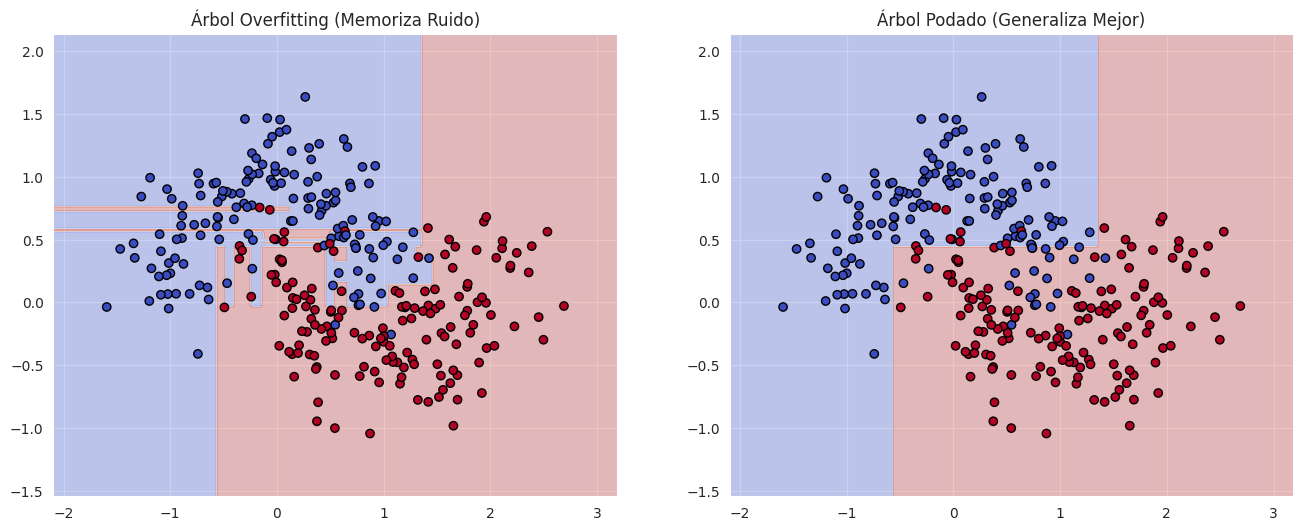

In [4]:
# Generamos datos complejos (Lunas con ruido)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Configuración de gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- EJERCICIO A: ÁRBOL SIN LÍMITES (OVERFITTING) ---
# TODO: Instancia un DecisionTreeClassifier SIN restricciones (max_depth=None)
tree_overfit = _____________________________
tree_overfit.fit(X, y)
plot_boundary(tree_overfit, X, y, "Árbol Overfitting (Memoriza Ruido)", ax=ax1)

# --- EJERCICIO B: ÁRBOL PODADO (REGULARIZADO) ---
# TODO: Instancia un árbol limitando la profundidad a 3 niveles
tree_pruned = DecisionTreeClassifier(max_depth=_____)
tree_pruned.fit(X, y)
plot_boundary(tree_pruned, X, y, "Árbol Podado (Generaliza Mejor)", ax=ax2)

plt.show()

# PREGUNTA: Fíjate en el gráfico de la izquierda. ¿Ves "islas" pequeñas de un color dentro del otro?
# Eso es el modelo aprendiendo excepciones que no existen (ruido).

## 3. El Torneo SOTA: Random Forest vs XGBoost
Vamos a usar un dataset real (**Cáncer de Mama**) para comparar los dos gigantes de la industria.

* **Random Forest:** Bagging (Paralelo). Robusto y fácil.
* **XGBoost:** Boosting (Secuencial). Agresivo y preciso.

In [ ]:
# Carga de datos
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# --- MODELO 1: RANDOM FOREST ---
# TODO: Crea un RandomForest con 100 árboles (n_estimators=100)
rf_model = _____________________________(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_model.predict(X_test))

# --- MODELO 2: XGBOOST ---
# TODO: Crea un XGBClassifier (usa valores por defecto)
xgb_model = _____________________________()
xgb_model.fit(X_train, y_train)
acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test))

print(f"🌲 Random Forest Accuracy: {acc_rf:.4f}")
print(f"🚀 XGBoost Accuracy:      {acc_xgb:.4f}")

# ANÁLISIS DE IMPORTANCIA (Feature Importance)
# Los árboles nos dicen qué variables importan más.
plt.figure(figsize=(10,5))
plt.barh(data.feature_names[:10], xgb_model.feature_importances_[:10])
plt.title("Top 10 Variables más importantes según XGBoost")
plt.show()

## 4. Aprendizaje No Supervisado: Topología de Datos
K-Means asume que los clústers son "bolas". DBSCAN busca zonas densas y formas raras.
Vamos a probarlos con datos en forma de **Lunas**.

In [ ]:
# Generamos datos con formas extrañas
X_moon, _ = make_moons(n_samples=400, noise=0.1, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- EJERCICIO A: K-MEANS ---
# TODO: Configura K-Means para buscar 2 grupos (n_clusters=2)
kmeans = ____________________(n_clusters=2, random_state=42)
y_km = kmeans.fit_predict(X_moon)

ax1.scatter(X_moon[:,0], X_moon[:,1], c=y_km, cmap='viridis')
ax1.set_title("K-Means (Corta geométricamente)")

# --- EJERCICIO B: DBSCAN ---
# TODO: Configura DBSCAN.
# Pista: eps=0.2 suele funcionar bien para estos datos. min_samples=5.
dbscan = ____________________(eps=_____, min_samples=5)
y_db = dbscan.fit_predict(X_moon)

ax2.scatter(X_moon[:,0], X_moon[:,1], c=y_db, cmap='viridis')
ax2.set_title("DBSCAN (Sigue la forma / densidad)")

plt.show()

## 5. Ingeniería de Producción: El Pipeline Definitivo
En producción no ejecutamos celdas sueltas. Empaquetamos todo (Preprocesamiento + Modelo) en un objeto sólido.
Además, usaremos **GridSearch** para que la máquina busque los mejores hiperparámetros por nosotros.

In [ ]:
# 1. Definimos los pasos del Pipeline
# Paso 'scaler': StandardScaler
# Paso 'classifier': RandomForestClassifier
pipe = Pipeline([
    ('scaler', ____________________),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Definimos la rejilla de Hiperparámetros a probar
# OJO: Usamos 'nombre_paso__parametro' (doble guion bajo)
param_grid = {
    'classifier__n_estimators': [50, 100, 200],      # Número de árboles
    'classifier__max_depth': [None, 5, 10]           # Profundidad máxima
}

# 3. Configuramos la Búsqueda (Grid Search) con Validación Cruzada (cv=5)
# TODO: Instancia GridSearchCV pasando el pipeline y la rejilla
search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

print("⏳ Entrenando y buscando hiperparámetros (esto puede tardar)...")
# Ajustamos sobre los datos de Train (del ejercicio de cáncer)
search.fit(X_train, y_train)

print("\n✅ ¡Búsqueda terminada!")
print(f"🏆 Mejor Modelo: {search.best_params_}")
print(f"📊 Accuracy en Validación: {search.best_score_:.4f}")

# 4. Evaluación Final en Test (Simulación de Producción)
final_model = search.best_estimator_
y_pred_final = final_model.predict(X_test)
print("\nReporte Final en Test Set:")
print(classification_report(y_test, y_pred_final))

## 🏆 Reto Final: Serialización
Has entrenado el modelo perfecto. Ahora guárdalo en un archivo para mandárselo al equipo de Backend.

**Librería:** `joblib`

In [ ]:
import joblib

# TODO: Guarda el 'final_model' en un archivo llamado 'modelo_cancer_v1.pkl'
joblib.dump(______________, 'modelo_cancer_v1.pkl')

print("💾 Modelo guardado en disco.")

# --- SIMULACIÓN DE CARGA EN PRODUCCIÓN ---
# TODO: Carga el modelo desde el archivo
modelo_cargado = joblib.load('___________________')

# Probamos que funciona prediciendo el primer paciente del test
prediccion = modelo_cargado.predict([X_test[0]])
print(f"🔮 Predicción del modelo cargado: {prediccion}")